# **Spatial Patterns of insect Diversity in continetal Ecuador**

## **Completeness analysis**

Author: Daning Montaño - Ocampo

# **1. Packages and libraries**

In [59]:
suppressMessages({
library(dplyr)
library(ggplot2)
library(sf)
library(iNEXT)
library(tidyr)
library(vegan)
library(tibble)
library(gstat)
library(ggplot2)
})
#library(doParallel)
#

# 2. Load clean data and grids

## 2.1. Ocurrences

In [ ]:
bio_records = read.csv( "../../../DATOS/Datasets/Biodiversidad/biodiversidad_ocurrences_clean.csv")|>
  filter(coordinateUncertaintyInMeters == 5000 )

# Transform to sf object
bio_records_sf = st_as_sf(
  bio_records,
  coords = c("decimalLongitude", "decimalLatitude"),
  crs = 4326
) |>
  st_transform(32717)

## 2.2. Grids

In [3]:
grids_1km_buffer = st_read("../../../DATOS/SHP/Grids/grid_zamora_ch_buffer_1km.shp")


Reading layer `grid_zamora_ch_buffer_1km' from data source `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Grids\grid_zamora_ch_buffer_1km.shp' using driver `ESRI Shapefile'
Simple feature collection with 15779 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 794083.7 ymax: 9631351
Projected CRS: WGS 84 / UTM zone 17S


# 3. Join points to grids

By locating the points, we will extract ID information from the grid tables. This allows us to work on the analyses and simply join the results to the grid, making the process more efficient.

In [4]:
recors_grid_1km_buffer <- st_join(
  bio_records_sf,
  grids_1km_buffer %>% select(id),   
  join = st_within                              # inside polygons
) %>%  mutate(
  Group = case_when(
    kingdom == "Plantae" ~ "Plants",
    kingdom == "Animalia" & class %in% c("Reptilia","Squamata") ~ "Reptilia",
    kingdom == "Animalia" & class %in% c("Amphibia","Aves","Mammalia") ~ class,
    TRUE ~ NA_character_
  )
)




# 4. Records and sp per 1 km grid

All

In [5]:
total_records_species_per_grid= recors_grid_1km_buffer |>
  as.data.frame() |>
  dplyr::group_by(id) |>
  dplyr::summarise(
    Total_records  = dplyr::n(),                     # número total de registros
    Total_species  = dplyr::n_distinct(scientificName) # número de especies únicas
  ) |>
  as.data.frame()


By group

In [6]:
total_records_species_per_grid_plants = recors_grid_1km_buffer |>
  as.data.frame() |>
  dplyr::filter(kingdom == "Plantae") |>
  dplyr::group_by(id) |>
  dplyr::summarise(
    Total_records  = dplyr::n(),                     # número total de registros
    Total_species  = dplyr::n_distinct(scientificName) # número de especies únicas
  ) |>
  mutate(Group = "Plants")|>
  as.data.frame()


total_records_species_per_grid_animals = recors_grid_1km_buffer |>
  as.data.frame() |>
  dplyr::filter(kingdom == "Animalia") |>
  dplyr::filter(class %in% c("Amphibia","Aves","Mammalia","Reptilia","Squamata")) |>
  dplyr::mutate(
    Group = dplyr::case_when(
      class %in% c("Reptilia","Squamata") ~ "Reptilia",
      TRUE ~ class
    )
  ) |>
  dplyr::group_by(Group, id) |>
  dplyr::summarise(
    Total_records = dplyr::n(),
    Total_species = dplyr::n_distinct(scientificName)
  ) |>
  as.data.frame()

total_record_sp_by_group = rbind(total_records_species_per_grid_plants, total_records_species_per_grid_animals)
total_record_sp_by_group


`summarise()` has grouped output by 'Group'. You can override using the `.groups` argument.


Join results to 1 km grid

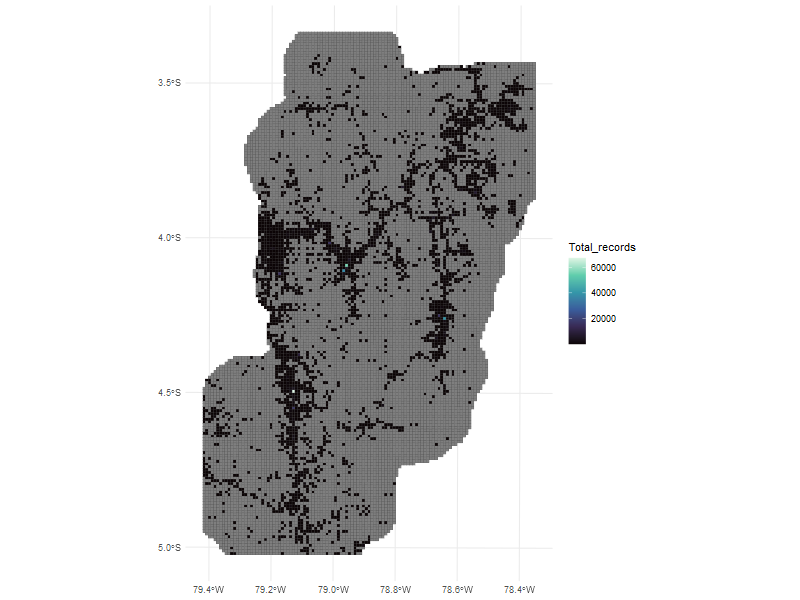

In [7]:
grids_1km_buffer_join = grids_1km_buffer%>% 
  left_join(total_records_species_per_grid, by = "id")

ggplot(grids_1km_buffer_join) +
  geom_sf(aes(fill = Total_records ), color = "grey30", size = 0.1) +
  scale_fill_viridis_c(option = "mako") +
  theme_minimal()

Warning messages:
1: Removed 12776 rows containing non-finite outside the scale range (`stat_smooth()`). 
2: Removed 12776 rows containing missing values or values outside the scale range (`geom_point()`). 


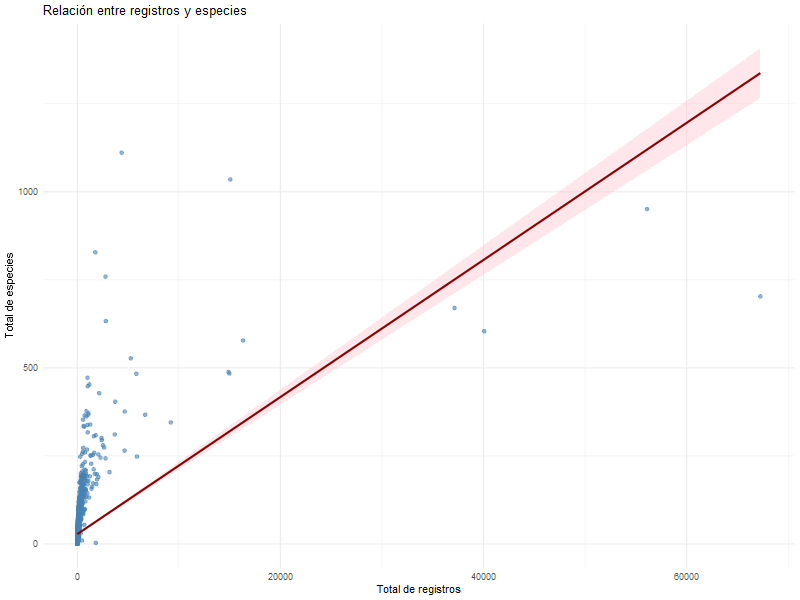

`geom_smooth()` using formula = 'y ~ x'

In [8]:
ggplot(grids_1km_buffer_join, aes(x = Total_records, y =  Total_species   )) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "darkred", fill = "pink") +
  theme_minimal() +
  labs(
    x = "Total de registros",
    y = "Total de especies",
    title = "Relación entre registros y especies"
  )

# 6. Sampling coverage

In [72]:
grid_conteo

Simple feature collection with 15779 features and 9 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 794083.7 ymax: 9631351
Projected CRS: WGS 84 / UTM zone 17S
First 10 features:
      id     left     top    right  bottom Total_records Total_species n_records                       geometry log_records
1  14262 751083.7 9582351 752083.7 9581351             7             7         7 POLYGON ((751083.7 9582351,...    2.079442
2  14263 751083.7 9581351 752083.7 9580351            23            10        23 POLYGON ((751083.7 9581351,...    3.178054
3  14260 751083.7 9584351 752083.7 9583351            NA            NA         0 POLYGON ((751083.7 9584351,...    0.000000
4  14261 751083.7 9583351 752083.7 9582351             6             3         6 POLYGON ((751083.7 9583351,...    1.945910
5  14258 751083.7 9586351 752083.7 9585351            NA            NA         0 POLYGON ((751083.7 9586351,...    0.000000
6  14259 751083.7 9585351 7

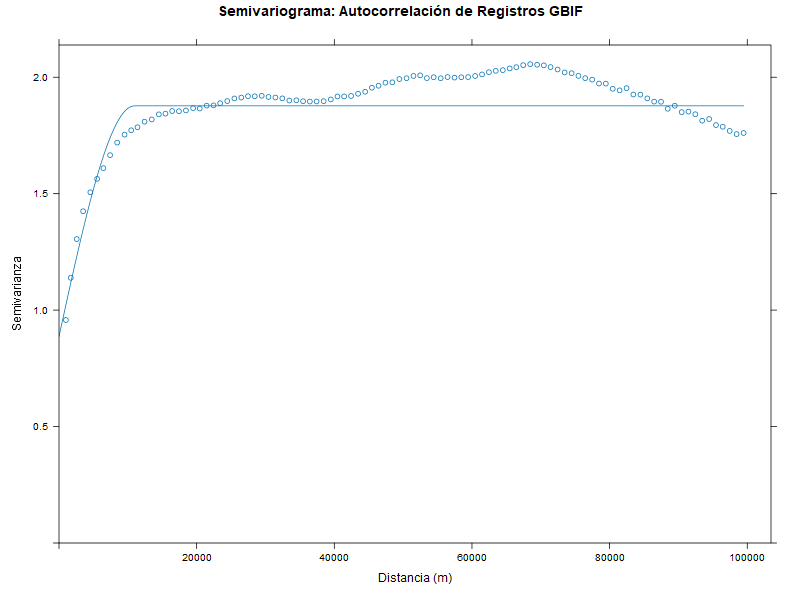

In [73]:


# 1. Preparar los datos
# Asegúrate de que el grid tenga el conteo de registros y coordenadas XY
grid_conteo <- grids_1km_buffer_join |>
  left_join(
    recors_grid_1km_buffer |> 
      st_drop_geometry() |> 
      group_by(id) |> 
      tally(name = "n_records"),
    by = "id"
  ) |>
  mutate(n_records = tidyr::replace_na(n_records, 0))

# Extraer coordenadas para gstat (necesita un objeto espacial tipo sp o sf)
# Es mejor usar una transformación logarítmica si los datos de registros son muy dispares
grid_conteo$log_records <- log1p(grid_conteo$n_records)

# 2. Calcular el Semivariograma Empírico
# 'log_records ~ 1' asume que no hay una tendencia (detrending) previa
v_empirico <- variogram(log_records ~ 1, grid_conteo, width = 1000, cutoff = 100000) 
# width = 2000 (bins de 2km), cutoff = 100km (distancia máxima a evaluar)

# 3. Ajustar un modelo al semivariograma (Esférico o Exponencial)
# vgm(psill, model, range, nugget)
# El 'range' inicial puede ser una estimación visual (ej. 20000m)
v_fit <- fit.variogram(v_empirico, vgm(psill = var(grid_conteo$log_records), 
                                       model = "Sph", 
                                       range = 30000, 
                                       nugget = 0.1))

# 4. Graficar el resultado
plot(v_empirico, v_fit, 
     main = "Semivariograma: Autocorrelación de Registros GBIF",
     xlab = "Distancia (m)", 
     ylab = "Semivarianza")

In [74]:
v_fit

  model     psill    range
1   Nug 0.8866176     0.00
2   Sph 0.9905443 10935.16

In [9]:
library(dplyr)
library(tidyr)
library(purrr)
library(sf)
library(iNEXT)

calc_coverage_3x3_group <- function(group_name,
                                    grid_sf,
                                    summary_df,
                                    records_sf) {
  
  #----------------------------------------------------------
  # 1. Preparar grid
  #----------------------------------------------------------
  grid_base <- grid_sf |>
    dplyr::select(id, geometry) |>
    dplyr::distinct(id, .keep_all = TRUE)
  
  # Crear col_idx y row_idx si no existen
  if (!all(c("col_idx", "row_idx") %in% names(grid_sf))) {
    
    cent <- sf::st_coordinates(sf::st_centroid(grid_base$geometry))
    
    x_vals <- sort(unique(round(cent[,1], 6)))
    y_vals <- sort(unique(round(cent[,2], 6)))
    
    cellsize_x <- min(diff(x_vals))
    cellsize_y <- min(diff(y_vals))
    
    xmin <- min(x_vals)
    ymin <- min(y_vals)
    
    grid_base <- grid_base |>
      dplyr::mutate(
        col_idx = round((cent[,1] - xmin) / cellsize_x),
        row_idx = round((cent[,2] - ymin) / cellsize_y)
      )
    
  } else {
    
    grid_base <- grid_sf |>
      dplyr::select(id, col_idx, row_idx, geometry) |>
      dplyr::distinct(id, .keep_all = TRUE)
  }
  
  #----------------------------------------------------------
  # 2. Filtrar celdas focales con información
  #----------------------------------------------------------
  focal_ids <- summary_df |>
    dplyr::filter(
      Group == group_name,
      !is.na(Total_records),
      Total_records > 0,
      !is.na(Total_species),
      Total_species > 0
    ) |>
    dplyr::distinct(id) |>
    dplyr::pull(id)
  
  if (length(focal_ids) == 0) {
    return(NULL)
  }
  
  #----------------------------------------------------------
  # 3. Filtrar registros del grupo
  #----------------------------------------------------------
  rec_group <- records_sf |>
    st_drop_geometry() |>
    dplyr::filter(
      Group == group_name,
      !is.na(id),
      !is.na(scientificName)
    ) |>
    dplyr::distinct(id, scientificName)
  
  if (nrow(rec_group) == 0) {
    return(NULL)
  }
  
  #----------------------------------------------------------
  # 4. Función auxiliar vecinos 3x3
  #----------------------------------------------------------
  get_neighbors_3x3 <- function(focal_id, grid_df) {
    focal_row <- grid_df[grid_df$id == focal_id, ]
    
    if (nrow(focal_row) == 0) return(integer(0))
    
    fc <- focal_row$col_idx[1]
    fr <- focal_row$row_idx[1]
    
    grid_df |>
      dplyr::filter(
        col_idx >= fc - 1, col_idx <= fc + 1,
        row_idx >= fr - 1, row_idx <= fr + 1
      ) |>
      dplyr::pull(id)
  }
  
  #----------------------------------------------------------
  # 5. Función auxiliar fila vacía
  #----------------------------------------------------------
  make_na_row <- function(focal_id) {
    data.frame(
      id = focal_id,
      Group = group_name,
      n_cells_window = NA_integer_,
      n_cells_sampled = NA_integer_,
      Sampling_coverage = NA_real_,
      sp_obs = NA_real_,
      Q1_uniques = NA_real_,
      Q2_duplicates = NA_real_,
      sc_ext = NA_real_,
      t_units_ext = NA_real_,
      sp_ext = NA_real_,
      stringsAsFactors = FALSE
    )
  }
  
  #----------------------------------------------------------
  # 6. Calcular completitud por celda focal
  #----------------------------------------------------------
  calc_one_cell <- function(focal_id) {
    
    window_ids <- get_neighbors_3x3(focal_id, grid_base)
    
    if (length(window_ids) == 0) {
      return(make_na_row(focal_id))
    }
    
    rec_window <- rec_group |>
      dplyr::filter(id %in% window_ids)
    
    n_cells_sampled <- rec_window |>
      dplyr::distinct(id) |>
      nrow()
    
    if (n_cells_sampled < 2) {
      return(make_na_row(focal_id))
    }
    
    pa_matrix <- rec_window |>
      dplyr::mutate(present = 1L) |>
      tidyr::pivot_wider(
        names_from = id,
        values_from = present,
        values_fill = 0L
      )
    
    pa_vals <- as.matrix(pa_matrix[, -1, drop = FALSE])
    
    T_units <- ncol(pa_vals)
    incid_counts <- rowSums(pa_vals)
    incid_counts <- incid_counts[incid_counts > 0]
    
    if (length(incid_counts) == 0) {
      return(make_na_row(focal_id))
    }
    
    incid_vec <- c(T_units, incid_counts)
    
    tryCatch({
      res <- iNEXT(
        list(site = incid_vec),
        q = 0,
        datatype = "incidence_freq",
        se = FALSE
      )
      
      cb <- res$iNextEst$coverage_based
      sb <- res$iNextEst$size_based
      
      data.frame(
        id = focal_id,
        Group = group_name,
        n_cells_window = length(window_ids),
        n_cells_sampled = n_cells_sampled,
        Sampling_coverage = res$DataInfo$SC,
        sp_obs = res$DataInfo$S.obs,
        Q1_uniques = res$DataInfo$Q1,
        Q2_duplicates = res$DataInfo$Q2,
        sc_ext = if (!is.null(cb) && nrow(cb) > 0) tail(cb$SC, 1) else NA_real_,
        t_units_ext = if (!is.null(sb) && nrow(sb) > 0) tail(sb$t, 1) else NA_real_,
        sp_ext = if (!is.null(cb) && nrow(cb) > 0) round(tail(cb$qD, 1), 0) else NA_real_,
        stringsAsFactors = FALSE
      )
      
    }, error = function(e) {
      make_na_row(focal_id)
    })
  }
  
  #----------------------------------------------------------
  # 7. Aplicar a todas las celdas focales del grupo
  #----------------------------------------------------------
  res_df <- purrr::map_dfr(focal_ids, calc_one_cell)
  
  #----------------------------------------------------------
  # 8. Unir al grid para dejar el valor en la celda central
  #----------------------------------------------------------
  res_sf <- grid_base |>
    dplyr::select(id, geometry) |>
    dplyr::right_join(res_df, by = "id") |>
    sf::st_as_sf()
  
  return(res_sf)
}

## 6.1. Plants

In [ ]:
coverage_plantae <- calc_coverage_3x3_group(
  group_name = "Plants",
  grid_sf = grids_1km_buffer_join,
  summary_df = total_record_sp_by_group,
  records_sf = recors_grid_1km_buffer
)

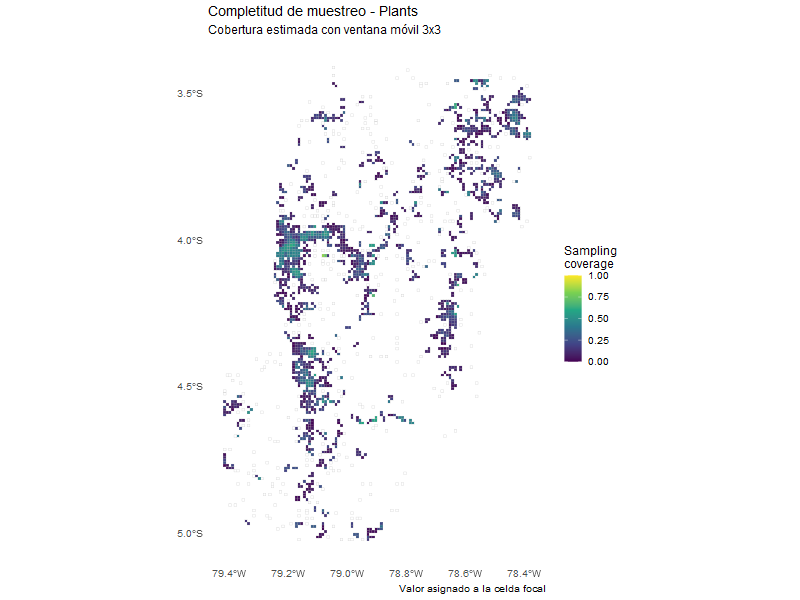

In [ ]:

ggplot() +
  geom_sf(
    data = coverage_plantae,
    aes(fill = Sampling_coverage),
    color = "grey70",
    linewidth = 0.1
  ) +
  scale_fill_viridis_c(
    name = "Sampling\ncoverage",
    na.value = "white",
    limits = c(0, 1)
  ) +
  labs(
    title = "Completitud de muestreo - Plants",
    subtitle = "Cobertura estimada con ventana móvil 3x3",
    caption = "Valor asignado a la celda focal"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.title = element_blank()
  )

## 6.2. Birds

In [12]:
coverage_aves <- calc_coverage_3x3_group(
  group_name = "Aves",
  grid_sf = grids_1km_buffer_join,
  summary_df = total_record_sp_by_group,
  records_sf = recors_grid_1km_buffer
)

In [25]:
View(coverage_aves)

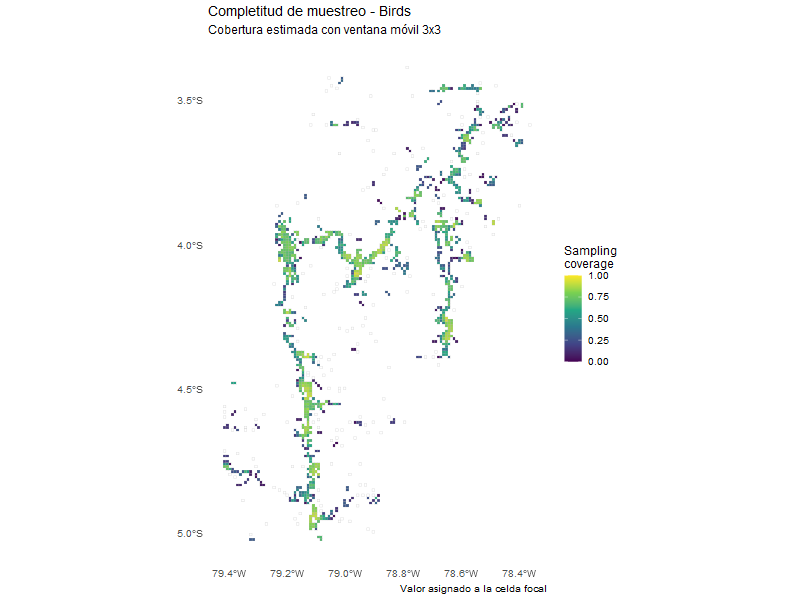

In [16]:

ggplot() +
  geom_sf(
    data = coverage_aves,
    aes(fill = Sampling_coverage),
    color = "grey70",
    linewidth = 0.1
  ) +
  scale_fill_viridis_c(
    name = "Sampling\ncoverage",
    na.value = "white",
    limits = c(0, 1)
  ) +
  labs(
    title = "Completitud de muestreo - Birds",
    subtitle = "Cobertura estimada con ventana móvil 3x3",
    caption = "Valor asignado a la celda focal"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.title = element_blank()
  )

## 6.3. Mammalia

In [17]:
coverage_mammalia <- calc_coverage_3x3_group(
  group_name = "Mammalia",
  grid_sf = grids_1km_buffer_join,
  summary_df = total_record_sp_by_group,
  records_sf = recors_grid_1km_buffer
)

In [26]:
View(coverage_mammalia)

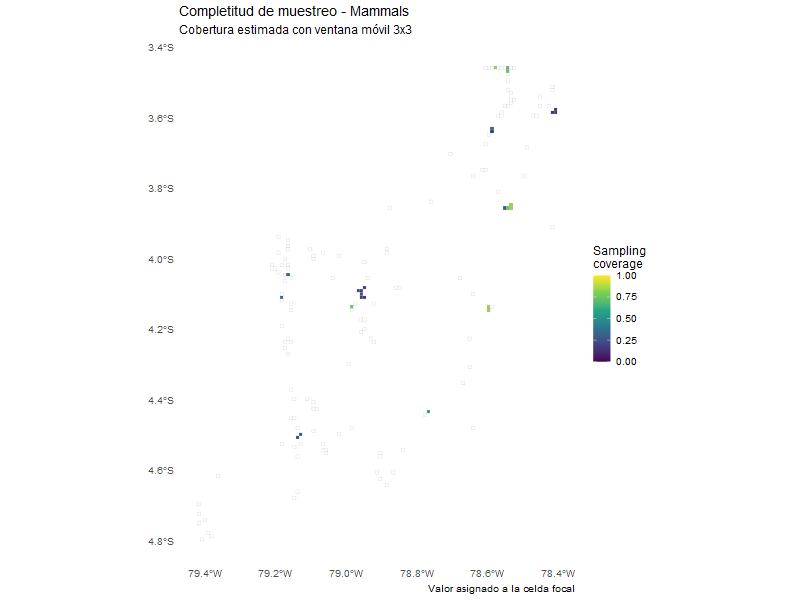

In [18]:

ggplot() +
  geom_sf(
    data = coverage_mammalia,
    aes(fill = Sampling_coverage),
    color = "grey70",
    linewidth = 0.1
  ) +
  scale_fill_viridis_c(
    name = "Sampling\ncoverage",
    na.value = "white",
    limits = c(0, 1)
  ) +
  labs(
    title = "Completitud de muestreo - Mammals",
    subtitle = "Cobertura estimada con ventana móvil 3x3",
    caption = "Valor asignado a la celda focal"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.title = element_blank()
  )

## 6.4. Amphibia

In [ ]:
coverage_amphibia <- calc_coverage_3x3_group(
  group_name = "Amphibia",
  grid_sf = grids_1km_buffer_join,
  summary_df = total_record_sp_by_group,
  records_sf = recors_grid_1km_buffer
)



Simple feature collection with 489 features and 11 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9449351 xmax: 793083.7 ymax: 9620351
Projected CRS: WGS 84 / UTM zone 17S
First 10 features:
      id    Group n_cells_window n_cells_sampled Sampling_coverage sp_obs Q1_uniques Q2_duplicates    sc_ext t_units_ext sp_ext
1  12483 Amphibia              9               3            0.8784     17          7             6 0.9810174           6     19
2  12468 Amphibia             NA              NA                NA     NA         NA            NA        NA          NA     NA
3  12466 Amphibia             NA              NA                NA     NA         NA            NA        NA          NA     NA
4  12406 Amphibia              9               2            0.2500      7          7             0 0.6276561           4     12
5  12296 Amphibia              9               3            0.8730     18          8            10 0.9888519           6     20
6  1

In [27]:
View(coverage_amphibia)

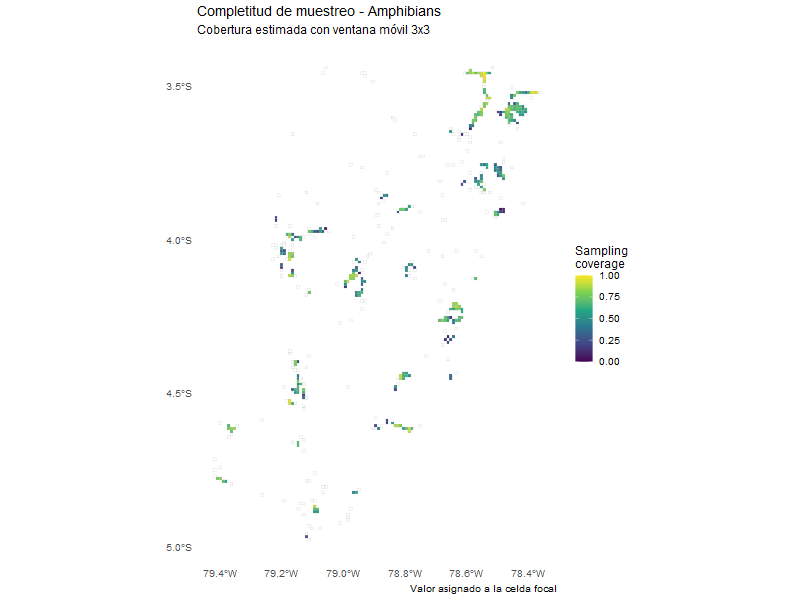

In [20]:
ggplot() +
  geom_sf(
    data = coverage_amphibia,
    aes(fill = Sampling_coverage),
    color = "grey70",
    linewidth = 0.1
  ) +
  scale_fill_viridis_c(
    name = "Sampling\ncoverage",
    na.value = "white",
    limits = c(0, 1)
  ) +
  labs(
    title = "Completitud de muestreo - Amphibians",
    subtitle = "Cobertura estimada con ventana móvil 3x3",
    caption = "Valor asignado a la celda focal"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.title = element_blank()
  )

## 6.5. Reptilia

In [21]:
coverage_reptilia <- calc_coverage_3x3_group(
  group_name = "Reptilia",
  grid_sf = grids_1km_buffer_join,
  summary_df = total_record_sp_by_group,
  records_sf = recors_grid_1km_buffer
)



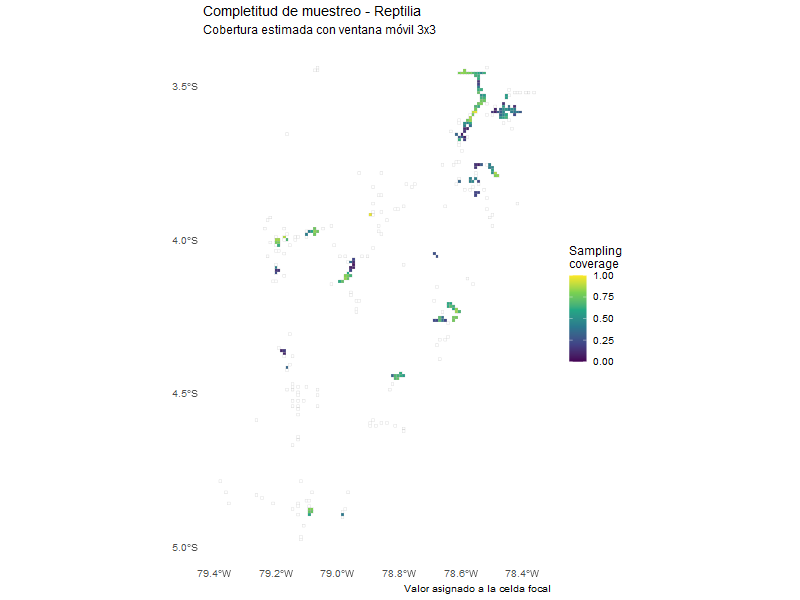

In [22]:
ggplot() +
  geom_sf(
    data = coverage_reptilia,
    aes(fill = Sampling_coverage),
    color = "grey70",
    linewidth = 0.1
  ) +
  scale_fill_viridis_c(
    name = "Sampling\ncoverage",
    na.value = "white",
    limits = c(0, 1)
  ) +
  labs(
    title = "Completitud de muestreo - Reptilia",
    subtitle = "Cobertura estimada con ventana móvil 3x3",
    caption = "Valor asignado a la celda focal"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.title = element_blank()
  )

In [60]:
library(dplyr)
library(tidyr)
library(purrr)
library(sf)
library(iNEXT)

calc_coverage_window_group <- function(group_name,
                                       grid_sf,
                                       summary_df,
                                       records_sf,
                                       k = 12) { # k es el radio (12km según tu semivariograma)
  
  # 1. Preparar grid con índices espaciales
  grid_base <- grid_sf |>
    dplyr::select(id, col_idx, row_idx, geometry) |>
    dplyr::distinct(id, .keep_all = TRUE)
  
  # 2. Filtrar IDs focales (solo celdas con datos del grupo específico)
  focal_ids <- summary_df |>
    dplyr::filter(
      Group == group_name,
      Total_records > 0,
      Total_species > 0
    ) |>
    dplyr::pull(id)
  
  if (length(focal_ids) == 0) return(NULL)
  
  # 3. Filtrar registros del grupo (Pre-procesado para velocidad)
  rec_group <- records_sf |>
    sf::st_drop_geometry() |>
    dplyr::filter(Group == group_name, !is.na(scientificName)) |>
    dplyr::distinct(id, scientificName)
  
  # 4. Función de cálculo por celda (Ahora con radio k)
  calc_one_cell <- function(focal_id) {
    
    focal_info <- grid_base[grid_base$id == focal_id, ]
    if (nrow(focal_info) == 0) return(NULL)
    
    # Definir ventana dinámica basada en k
    fc <- focal_info$col_idx
    fr <- focal_info$row_idx
    
    window_ids <- grid_base |>
      dplyr::filter(
        col_idx >= (fc - k), col_idx <= (fc + k),
        row_idx >= (fr - k), row_idx <= (fr + k)
      ) |>
      dplyr::pull(id)
    
    # Registros dentro de la ventana de (2k+1)x(2k+1)
    rec_window <- rec_group |> dplyr::filter(id %in% window_ids)
    
    # iNEXT necesita al menos 2 unidades de muestreo (grids) con datos
    n_cells_sampled <- length(unique(rec_window$id))
    
    if (n_cells_sampled < 2) {
      return(data.frame(id = focal_id, Group = group_name, Sampling_coverage = NA_real_))
    }
    
    # Preparar vector de frecuencias de incidencia para iNEXT
    # Formato: c(Total_unidades, freq_sp1, freq_sp2, ...)
    incid_counts <- rec_window |>
      dplyr::group_by(scientificName) |>
      dplyr::tally() |>
      dplyr::pull(n)
    
    incid_vec <- c(n_cells_sampled, incid_counts)
    
    tryCatch({
      res <- iNEXT(incid_vec, q = 0, datatype = "incidence_freq", se = FALSE)
      
      # Extraer métricas clave
      # Sampling_coverage (SC) es la completitud actual
      data.frame(
        id = focal_id,
        Group = group_name,
        n_cells_window = length(window_ids), # Cuántas celdas existen en el radio
        n_cells_sampled = n_cells_sampled,   # Cuántas de esas tienen datos
        Sampling_coverage = res$DataInfo$SC,
        sp_obs = res$DataInfo$S.obs,
        Q1_uniques = res$DataInfo$Q1,
        Q2_duplicates = res$DataInfo$Q2,
        stringsAsFactors = FALSE
      )
    }, error = function(e) return(NULL))
  }
  
  # 5. Ejecutar mapeo (considera usar furrr::future_map para paralelizar si es muy lento)
  res_df <- purrr::map_dfr(focal_ids, calc_one_cell)
  
  # 6. Re-unir con geometría
  if (nrow(res_df) == 0) return(NULL)
  
  grid_base |>
    dplyr::select(id, geometry) |>
    dplyr::inner_join(res_df, by = "id")
}

In [ ]:
# 1. Definir el nombre exacto del grupo (revisa tus datos con unique(summary_df$Group))
nombre_grupo <- "Plants"

# 2. Ejecutar la función solo para este grupo
# Usamos k = 12 (radio de 12km) como determinamos con el semivariograma
completitud_plantas_sf <- calc_coverage_window_group(
    group_name = nombre_grupo,
    grid_sf = grids_1km_buffer_join,
    summary_df = summary_df,
    records_sf = recors_grid_1km_buffer,
    k = 10
)

: [1m[33mError[39m in `dplyr::select()`:[22m
[33m![39m Can't select columns that don't exist.
[31m✖[39m Column `col_idx` doesn't exist.

In [64]:


calc_coverage_window_group <- function(group_name,
                                       grid_sf,
                                       summary_df,
                                       records_sf,
                                       window_size = 25) { # <--- Tú pones el tamaño aquí (ej. 25)
  
  #----------------------------------------------------------
  # 1. Preparar grid e índices
  #----------------------------------------------------------
  grid_base <- grid_sf |>
    dplyr::select(id, geometry) |>
    dplyr::distinct(id, .keep_all = TRUE)
  
  # Cálculo automático de índices si no existen
  if (!all(c("col_idx", "row_idx") %in% names(grid_sf))) {
    cent <- sf::st_coordinates(sf::st_centroid(grid_base$geometry))
    x_vals <- sort(unique(round(cent[,1], 6)))
    y_vals <- sort(unique(round(cent[,2], 6)))
    cellsize_x <- min(diff(x_vals))
    cellsize_y <- min(diff(y_vals))
    
    grid_base <- grid_base |>
      dplyr::mutate(
        col_idx = round((cent[,1] - min(x_vals)) / cellsize_x),
        row_idx = round((cent[,2] - min(y_vals)) / cellsize_y)
      )
  } else {
    grid_base <- grid_sf |>
      dplyr::select(id, col_idx, row_idx, geometry) |>
      dplyr::distinct(id, .keep_all = TRUE)
  }
  
  #----------------------------------------------------------
  # 2. Calcular el Radio (k) basado en el window_size
  #----------------------------------------------------------
  # Si pides 25, el radio es (25 - 1) / 2 = 12
  k <- floor((window_size - 1) / 2)
  
  #----------------------------------------------------------
  # 3. Filtrar celdas y registros
  #----------------------------------------------------------
  focal_ids <- summary_df |>
    dplyr::filter(Group == group_name, Total_records > 0) |>
    dplyr::distinct(id) |>
    dplyr::pull(id)
  
  if (length(focal_ids) == 0) return(NULL)
  
  rec_group <- records_sf |>
    sf::st_drop_geometry() |>
    dplyr::filter(Group == group_name, !is.na(scientificName)) |>
    dplyr::distinct(id, scientificName)

  #----------------------------------------------------------
  # 4. Funciones auxiliares
  #----------------------------------------------------------
  make_na_row <- function(focal_id) {
    data.frame(id = focal_id, Group = group_name, Sampling_coverage = NA_real_, stringsAsFactors = FALSE)
  }

  calc_one_cell <- function(focal_id) {
    focal_row <- grid_base[grid_base$id == focal_id, ]
    if (nrow(focal_row) == 0) return(make_na_row(focal_id))
    
    fc <- focal_row$col_idx[1]
    fr <- focal_row$row_idx[1]
    
    # Filtro dinámico usando el radio k calculado
    window_ids <- grid_base |>
      dplyr::filter(
        col_idx >= fc - k, col_idx <= fc + k,
        row_idx >= fr - k, row_idx <= fr + k
      ) |>
      dplyr::pull(id)
    
    rec_window <- rec_group |> dplyr::filter(id %in% window_ids)
    n_cells_sampled <- length(unique(rec_window$id))
    
    if (n_cells_sampled < 2) return(make_na_row(focal_id))
    
    incid_counts <- rec_window |> group_by(scientificName) |> tally() |> pull(n)
    incid_vec <- c(n_cells_sampled, incid_counts)
    
    tryCatch({
      res <- iNEXT(incid_vec, q = 0, datatype = "incidence_freq", se = FALSE)
      data.frame(
        id = focal_id,
        Group = group_name,
        window_size_used = paste0(window_size, "x", window_size),
        n_cells_sampled = n_cells_sampled,
        Sampling_coverage = res$DataInfo$SC,
        sp_obs = res$DataInfo$S.obs,
        stringsAsFactors = FALSE
      )
    }, error = function(e) make_na_row(focal_id))
  }

  #----------------------------------------------------------
  # 5. Ejecutar y retornar SF
  #----------------------------------------------------------
  message(paste0("Calculando completitud para ", group_name, " usando ventana de ", window_size, "x", window_size, "..."))
  res_df <- purrr::map_dfr(focal_ids, calc_one_cell)
  
  return(grid_base |> dplyr::select(id, geometry) |> dplyr::inner_join(res_df, by = "id"))
}

In [66]:
summary_df

: [1m[33mError[39m:[22m
[33m![39m object 'summary_df' not found

In [97]:
# Para Plantas con ventana de 25x25 (basado en tu semivariograma)
plantas_25km <- calc_coverage_window_group(
  group_name = "Plants",
  grid_sf = grids_1km_buffer_join,
  summary_df = total_record_sp_by_group,
  records_sf = recors_grid_1km_buffer,
  window_size = 3 # <--- Aquí pones el tamaño directo
)

Calculando completitud para Plants usando ventana de 3x3...


In [98]:
plantas_25km

Simple feature collection with 2075 features and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 791083.7 ymax: 9623351
Projected CRS: WGS 84 / UTM zone 17S
First 10 features:
      id  Group Sampling_coverage window_size_used n_cells_sampled sp_obs                       geometry
1  14261 Plants            0.2899              3x3               4      8 POLYGON ((751083.7 9583351,...
2  14251 Plants                NA             <NA>              NA     NA POLYGON ((751083.7 9593351,...
3  14109 Plants                NA             <NA>              NA     NA POLYGON ((750083.7 9548351,...
4  12483 Plants            0.4570              3x3               4     74 POLYGON ((741083.7 9491351,...
5  12418 Plants            0.1202              3x3               4     42 POLYGON ((741083.7 9556351,...
6  12419 Plants            0.1202              3x3               4     42 POLYGON ((741083.7 9555351,...
7  12296 Plants            0.1862    

In [100]:
View(plantas_25km)

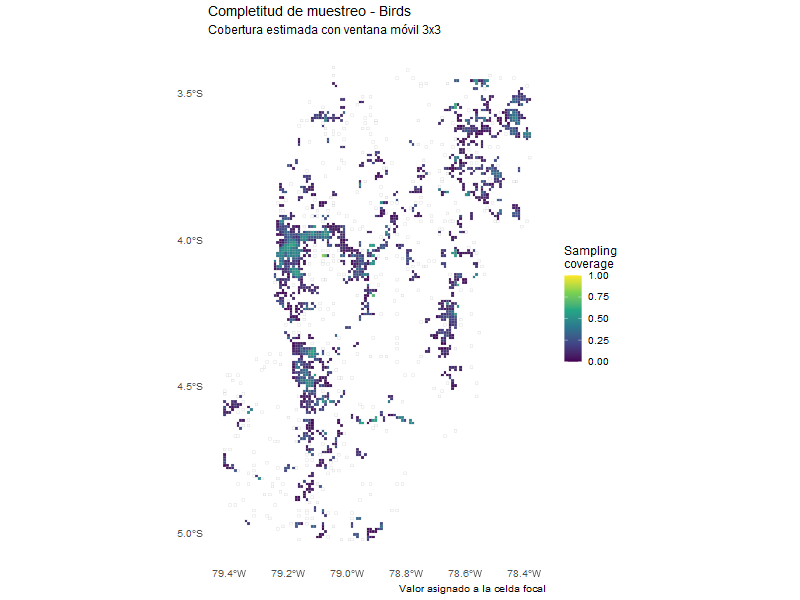

In [99]:

ggplot() +
  geom_sf(
    data = plantas_25km,
    aes(fill = Sampling_coverage),
    color = "grey70",
    linewidth = 0.1
  ) +
  scale_fill_viridis_c(
    name = "Sampling\ncoverage",
    na.value = "white",
    limits = c(0, 1)
  ) +
  labs(
    title = "Completitud de muestreo - Birds",
    subtitle = "Cobertura estimada con ventana móvil 3x3",
    caption = "Valor asignado a la celda focal"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.title = element_blank()
  )

In [ ]:
coverage_reptilia <- calc_coverage_3x3_group(
  group_name = "Reptilia",
  grid_sf = grids_1km_buffer_join,
  summary_df = total_record_sp_by_group,
  records_sf = recors_grid_1km_buffer
)


In [102]:
# ============================================================
# ANÁLISIS DE SENSIBILIDAD: VENTANA MÓVIL - UN SOLO GRUPO
# ============================================================

# --- Parámetros que tú defines ---
GROUP_NAME   <- "Aves"           # <-- cambia aquí tu grupo
WINDOW_SIZES <- c(3, 5, 7, 9, 11, 13, 15, 19, 25)  # ventanas a evaluar

# --- Ciclo de sensibilidad ---
sensitivity_results <- vector("list", length(WINDOW_SIZES))
names(sensitivity_results) <- paste0(WINDOW_SIZES, "x", WINDOW_SIZES)

for (i in seq_along(WINDOW_SIZES)) {
  
  ws <- WINDOW_SIZES[i]
  message("\n[", i, "/", length(WINDOW_SIZES), "] Probando ventana: ", ws, "x", ws,
          " (", ws^2, " km²)")
  
  result <- calc_coverage_window_group(
    group_name  = GROUP_NAME,
    grid_sf     = grids_1km_buffer_join,
    summary_df  = total_record_sp_by_group,
    records_sf  = recors_grid_1km_buffer,
    window_size = ws
  )
  
  if (is.null(result)) {
    message("  >> Sin resultados para window_size = ", ws)
    next
  }
  
  # Resumen estadístico de esta ventana
  summary_ws <- result |>
    sf::st_drop_geometry() |>
    summarise(
      Group        = GROUP_NAME,
      window_size  = ws,
      area_km2     = ws^2,
      n_valid      = sum(!is.na(Sampling_coverage)),
      pct_NA       = round(mean(is.na(Sampling_coverage)) * 100, 1),
      mean_SC      = round(mean(Sampling_coverage, na.rm = TRUE), 3),
      median_SC    = round(median(Sampling_coverage, na.rm = TRUE), 3),
      sd_SC        = round(sd(Sampling_coverage, na.rm = TRUE), 3),
      cv_SC        = round(sd_SC / mean_SC, 3),
      q25_SC       = round(quantile(Sampling_coverage, 0.25, na.rm = TRUE), 3),
      q75_SC       = round(quantile(Sampling_coverage, 0.75, na.rm = TRUE), 3)
    )
  
  sensitivity_results[[i]] <- list(
    summary = summary_ws,
    sf      = result       # guarda el sf completo si lo necesitas después
  )
  
  message("  >> n_válidas=", summary_ws$n_valid,
          " | %NA=",   summary_ws$pct_NA,
          " | SC_mean=", summary_ws$mean_SC,
          " | CV=",    summary_ws$cv_SC)
}

# --- Tabla resumen consolidada ---
sensitivity_df <- purrr::map_dfr(
  sensitivity_results, 
  ~ if (!is.null(.x)) .x$summary
)

print(sensitivity_df)


[1/9] Probando ventana: 3x3 (9 km²)
Calculando completitud para Aves usando ventana de 3x3...
  >> n_válidas=1124 | %NA=14.7 | SC_mean=0.525 | CV=0.495

[2/9] Probando ventana: 5x5 (25 km²)
Calculando completitud para Aves usando ventana de 5x5...
  >> n_válidas=1238 | %NA=6.1 | SC_mean=0.654 | CV=0.372

[3/9] Probando ventana: 7x7 (49 km²)
Calculando completitud para Aves usando ventana de 7x7...
  >> n_válidas=1276 | %NA=3.2 | SC_mean=0.723 | CV=0.322

[4/9] Probando ventana: 9x9 (81 km²)
Calculando completitud para Aves usando ventana de 9x9...
  >> n_válidas=1299 | %NA=1.4 | SC_mean=0.778 | CV=0.27

[5/9] Probando ventana: 11x11 (121 km²)
Calculando completitud para Aves usando ventana de 11x11...
  >> n_válidas=1304 | %NA=1.1 | SC_mean=0.819 | CV=0.23

[6/9] Probando ventana: 13x13 (169 km²)
Calculando completitud para Aves usando ventana de 13x13...
  >> n_válidas=1310 | %NA=0.6 | SC_mean=0.845 | CV=0.206

[7/9] Probando ventana: 15x15 (225 km²)
Calculando completitud para Aves 

  Group window_size area_km2 n_valid pct_NA mean_SC median_SC sd_SC cv_SC q25_SC q75_SC
1  Aves           3        9    1124   14.7   0.525     0.580 0.260 0.495  0.301  0.746
2  Aves           5       25    1238    6.1   0.654     0.737 0.243 0.372  0.524  0.845
3  Aves           7       49    1276    3.2   0.723     0.814 0.233 0.322  0.630  0.888
4  Aves           9       81    1299    1.4   0.778     0.862 0.210 0.270  0.723  0.915
5  Aves          11      121    1304    1.1   0.819     0.894 0.188 0.230  0.791  0.932
6  Aves          13      169    1310    0.6   0.845     0.911 0.174 0.206  0.832  0.945
7  Aves          15      225    1313    0.4   0.867     0.926 0.154 0.178  0.863  0.952


In [105]:
sensitivity_results$`15x15`

$summary
  Group window_size area_km2 n_valid pct_NA mean_SC median_SC sd_SC cv_SC q25_SC q75_SC
1  Aves          15      225    1313    0.4   0.867     0.926 0.154 0.178  0.863  0.952

$sf
Simple feature collection with 1318 features and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 793083.7 ymax: 9626351
Projected CRS: WGS 84 / UTM zone 17S
First 10 features:
      id Group window_size_used n_cells_sampled Sampling_coverage sp_obs                       geometry
1  14262  Aves            15x15              37            0.9097    291 POLYGON ((751083.7 9582351,...
2  14263  Aves            15x15              39            0.9120    291 POLYGON ((751083.7 9581351,...
3  14249  Aves            15x15               8            0.7938    171 POLYGON ((751083.7 9595351,...
4  14093  Aves            15x15              33            0.9193    392 POLYGON ((750083.7 9564351,...
5  14080  Aves            15x15              39            0.9

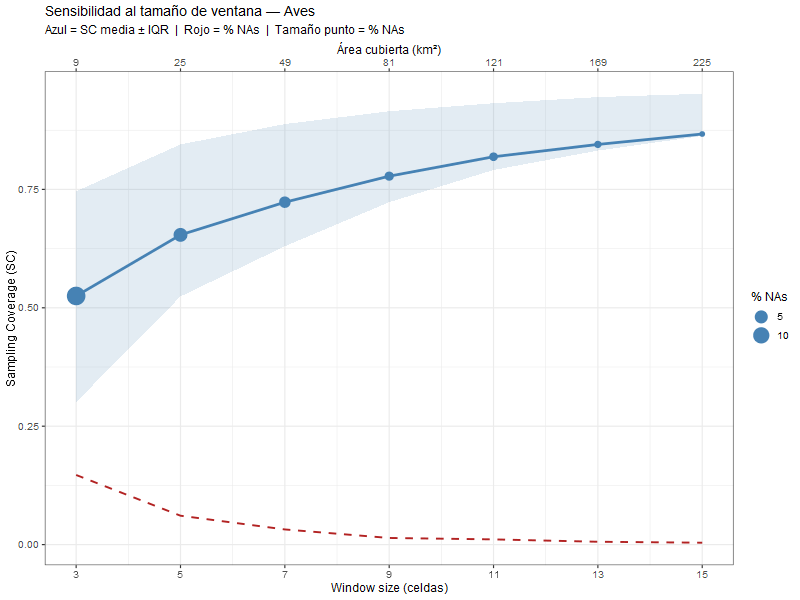

In [103]:
library(ggplot2)

# Cambio marginal entre ventanas consecutivas
sensitivity_df <- sensitivity_df |>
  dplyr::arrange(window_size) |>
  dplyr::mutate(
    delta_SC = abs(mean_SC - dplyr::lag(mean_SC)) / dplyr::lag(mean_SC) * 100
  )

# Gráfico de decisión
ggplot(sensitivity_df, aes(x = window_size)) +
  geom_ribbon(aes(ymin = q25_SC, ymax = q75_SC), alpha = 0.15, fill = "steelblue") +
  geom_line(aes(y = mean_SC), color = "steelblue", linewidth = 1.3) +
  geom_point(aes(y = mean_SC, size = pct_NA), color = "steelblue") +
  geom_line(aes(y = pct_NA / 100), color = "firebrick",
            linetype = "dashed", linewidth = 0.9) +
  scale_size_continuous(name = "% NAs", range = c(2, 8)) +
  scale_x_continuous(breaks = WINDOW_SIZES,
                     sec.axis = sec_axis(~ .^2, name = "Área cubierta (km²)",
                                         breaks = WINDOW_SIZES^2)) +
  labs(
    title    = paste0("Sensibilidad al tamaño de ventana — ", GROUP_NAME),
    subtitle = "Azul = SC media ± IQR  |  Rojo = % NAs  |  Tamaño punto = % NAs",
    x        = "Window size (celdas)",
    y        = "Sampling Coverage (SC)"
  ) +
  theme_bw(base_size = 12)

# 7. Exportar resultados

In [23]:

 #st_write(results_sampling_effor, "Results/shp/grid_10km_sampling.shp", append=FALSE)
 #st_write(results_sampling_effor_filter, "Results/shp/grid_10km_sampling_filter.shp", append=FALSE)